We will discuss the performance of **finetuning all parameters** versus **finetuning the last layer's parameters**. The experimental results will reveal that if we can the last layer's parameters to save the computing costs without significant performance degradtion.

In [1]:
import datetime
import os
import pickle
import sys

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm

os.chdir('../..')
sys.path.append('.')
from utils.dataset import load_cv_dataset
from utils.nn import set_seed

device = torch.device('cuda:0')
set_seed(0)

In [2]:
USE_CACHE = True    # please set to `False` ans specify `cache_name` if you want to override the old cache.
CACHE_DIR = './results/.cache/analysis/image-embedding/pretrained-ViT-finetune'
os.makedirs(CACHE_DIR, exist_ok=True)

In [3]:
def _train(dataloader, model, embed, optimizer, criterion, scaler, schedule=None):
    batch_loss, batch_acc = 0, 0
    for x, y in dataloader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        with torch.no_grad():
            e = embed(x)
            e = e if isinstance(e, torch.Tensor) else e[0]
        with torch.cuda.amp.autocast():
            pred = model(e)
            pred = pred if isinstance(pred, torch.Tensor) else pred[0]
        loss = criterion(pred, y)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        batch_loss += loss.detach().cpu().item()
        batch_acc  += torch.argmax(pred, dim=1).eq(y).sum().item() / y.size(0)
    if schedule: schedule.step()
    return (batch_loss / len(dataloader), batch_acc / len(dataloader) * 100)

In [4]:
def _test(dataloader, model, embed, criterion):
    batch_loss, batch_acc = 0, 0
    for x, y in dataloader:
        x, y = x.to(device), y.to(device)
        with torch.no_grad():
            e    = embed(x)
            e    = e if isinstance(e, torch.Tensor) else e[0]
            pred = model(e)
            pred = pred if isinstance(pred, torch.Tensor) else pred[0]
            loss = criterion(pred, y)
        batch_loss += loss.detach().cpu().item()
        batch_acc  += torch.argmax(pred, dim=1).eq(y).sum().item() / y.size(0)
    return (batch_loss / len(dataloader), batch_acc / len(dataloader) * 100)

In [5]:
def _finetune(model, trainloader, testloader, epoch, lr, gamma, embed=nn.Identity()):
    """
    :input model: model to finetune.
    :input embed: feature embedding without back-propagation, default: nn.Identity().
    :input cache_name: perfix name of cache file, default: None.
    """
    scaler    = torch.cuda.amp.GradScaler()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    schedule  = torch.optim.lr_scheduler.StepLR(optimizer, 1, gamma)

    train_losses, train_accs = list(), list()
    test_losses, test_accs   = list(), list()

    # test epoch 0.
    tset_loss, test_acc = _test(testloader, model, embed, criterion)
    test_losses.append(tset_loss)
    test_accs.append(test_acc)

    for _ in tqdm(range(epoch)):
        # train.
        train_loss, train_acc = _train(trainloader, model, embed, optimizer, criterion, scaler, schedule)
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        # test.
        tset_loss, test_acc = _test(testloader, model, embed, criterion)
        test_losses.append(tset_loss)
        test_accs.append(test_acc)
    return train_losses, train_accs, test_losses, test_accs

In [6]:
def finetune(model, trainloader, testloader, epoch, lr, gamma, embed=nn.Identity(), cache_name=None):
    """
    :input model: model to finetune.
    :input embed: feature embedding without back-propagation, default: nn.Identity().
    :input cache_name: perfix name of cache file, default: None.
    """
    # load cache.
    if cache_name and USE_CACHE:
        cache_file = os.path.join(CACHE_DIR, f'{cache_name}-{epoch}.pkl')
        if os.path.isfile(cache_file):
            date = datetime.datetime.fromtimestamp(os.path.getmtime(cache_file)).strftime('%Y-%M-%d %H:%m:%S')
            print(f"load cache (create at {date}) from '{cache_file}'.")
            with open(cache_file, 'rb') as f:
                return pickle.load(f)
    
    # finetune.
    train_loss, train_acc, test_loss, test_acc = _finetune(model, trainloader, testloader, epoch, lr, gamma, embed)
    
    # save cache.
    if cache_name:
        cache_file = os.path.join(CACHE_DIR, f'{cache_name}-{epoch}.pkl')
        print(f"create / override cache to '{cache_file}'.")
        with open(cache_file, 'wb') as f:
            pickle.dump((train_loss, train_acc, test_loss, test_acc), f)
    
    return train_loss, train_acc, test_loss, test_acc

In [13]:
def plot(train_loss, train_acc, test_loss, test_acc):
    x = list(range(1, len(train_loss) + 1))
    fig, ax = plt.subplots(1, 2, figsize=(9, 3), dpi=100)
    ax[0].grid(linestyle='--', alpha=0.5)
    ax[0].plot(x, train_loss, label='Train Loss')
    ax[0].plot([0] + x, test_loss, label='Test Loss')
    ax[0].set_xlim([0, x[-1]])
    ax[0].legend(loc='upper right')
    ax[0].set_xlabel('Epochs')
    ax[0].set_ylabel('Cross-Entropy Loss')
    ax[1].grid(linestyle='--', alpha=0.5)
    ax[1].plot(x, train_acc, label='Train Acc')
    ax[1].plot([0] + x, test_acc, label='Test Acc')
    ax[1].set_xlim([0, x[-1]])
    ax[1].legend(loc='upper left')
    ax[1].set_xlabel('Epochs')
    ax[1].set_ylabel('Accuracy (%)')
    fig.tight_layout()
    fig.show()

### Experiment Setting

##### Datasets
We will analyze the performance of the aforementioned models on:
* two low-resolution datasets (*i.e.*, CIFAR-10 and CIFAR-100); 
* and three relatively high-resolution datasets (*i.e.*, CalTech-256 and ImageNet-1k).

##### Models
We will perform experiments on the following pretrained Transformer-based models:
* ViT ():
* MAE ():
* BEiT ():

These models are all pretrained on the ImageNet-21k dataset.

In [8]:
from transformers import ViTForImageClassification, ViTMAEModel, BeitForImageClassification

vit_name  = 'google/vit-base-patch16-224-in21k'
mae_name  = 'facebook/vit-mae-base'
beit_name = 'microsoft/beit-base-patch16-224'


class ViTMAE(nn.Module):

    def __init__(self, num_labels) -> None:
        super().__init__()
        self.mae = ViTMAEModel.from_pretrained(mae_name, return_dict=False)
        self.linear = nn.Linear(self.mae.layernorm.normalized_shape[0], num_labels)

    def forward(self, x):
        e = self.mae(x)[0][:,0]
        return self.linear(e)
    

class ViTMAEEncoder(nn.Module):

    def __init__(self) -> None:
        super().__init__()
        self.mae = ViTMAEModel.from_pretrained(mae_name, return_dict=False)

    def forward(self, x):
        return self.mae(x)[0][:,0]

### 1. Performance of Pre-trained Models over Low Resolution Dataset

First we load CIFAR-10 / CIFAR-100 dataset without augmentation transform and resize to $224 \times 224$.

In [9]:
bs = 128

cifar10_trainset    = load_cv_dataset('cifar10', train=True, augment=False, resize=224)
cifar10_testset     = load_cv_dataset('cifar10', train=False, augment=False, resize=224)
cifar10_trainloader = DataLoader(cifar10_trainset, batch_size=bs, shuffle=True, num_workers=0)
cifar10_testloader  = DataLoader(cifar10_testset, batch_size=bs, shuffle=False, num_workers=0)
print('CIFAR-10 training transform:\n' + '\n'.join([f'==> {str(t)}' for t in cifar10_trainset.transform.transforms]))
print('CIFAR-10 test transform:\n' + '\n'.join([f'==> {str(t)}' for t in cifar10_testset.transform.transforms]))

cifar100_trainset    = load_cv_dataset('cifar100', train=True, augment=False, resize=224)
cifar100_testset     = load_cv_dataset('cifar100', train=False, augment=False, resize=224)
cifar100_trainloader = DataLoader(cifar100_trainset, batch_size=bs, shuffle=True, num_workers=0)
cifar100_testloader  = DataLoader(cifar100_testset, batch_size=bs, shuffle=False, num_workers=0)
print('CIFAR-100 training transform:\n' + '\n'.join([f'==> {str(t)}' for t in cifar100_trainset.transform.transforms]))
print('CIFAR-100 test transform:\n' + '\n'.join([f'==> {str(t)}' for t in cifar100_testset.transform.transforms]))

CIFAR-10 training transform:
==> Resize(size=224, interpolation=bilinear, max_size=None, antialias=None)
==> ToTensor()
==> Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.2023, 0.1994, 0.201))
CIFAR-10 test transform:
==> Resize(size=224, interpolation=bilinear, max_size=None, antialias=None)
==> ToTensor()
==> Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.2023, 0.1994, 0.201))
CIFAR-100 training transform:
==> Resize(size=224, interpolation=bilinear, max_size=None, antialias=None)
==> ToTensor()
==> Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.2023, 0.1994, 0.201))
CIFAR-100 test transform:
==> Resize(size=224, interpolation=bilinear, max_size=None, antialias=None)
==> ToTensor()
==> Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.2023, 0.1994, 0.201))


### 1.1 Fintune ViT over CIFAR Family
We first discuss **finetuning all** parameters of *ViT* versus finetuning **the last layer's parameters** of *ViT* over CIFAR-10 / CIFAR-100.

In [10]:
epoch_all  = 10
epoch_last = 30
lr    = 1e-2
gamma = 0.95

#### 1.1.1 Fintune ViT over CIFAR-10

In [11]:
vit_finetune_all                  = ViTForImageClassification.from_pretrained(vit_name, num_labels=len(cifar10_trainset.classes), return_dict=False).to(device)
vit_finetune_last_embed           = ViTForImageClassification.from_pretrained(vit_name, num_labels=len(cifar10_trainset.classes), return_dict=False).to(device)
vit_finetune_last_classifier       = nn.Linear(vit_finetune_last_embed.classifier.in_features, len(cifar10_trainset.classes)).to(device)
vit_finetune_last_embed.classifier = nn.Identity().to(device)

Some weights of the model checkpoint at google/vit-base-patch16-224-in21k were not used when initializing ViTForImageClassification: ['pooler.dense.bias', 'pooler.dense.weight']
- This IS expected if you are initializing ViTForImageClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing ViTForImageClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of the model checkp

Results of finetuning all parameters versus finetuning the last layer's parameters of **ViT** over CIFAR-10. 

The total time comsumption of finetuning all parameters is , while the total time comsumption of finetuning the last layer's parameters is (all are conduced on one Nvidia RTX 3090).

load cache (create at 2023-52-07 07:06:52) from './results/.cache/analysis/image-embedding/pretrained-ViT-finetune/cifar10_vit_finetune_all-10.pkl'.


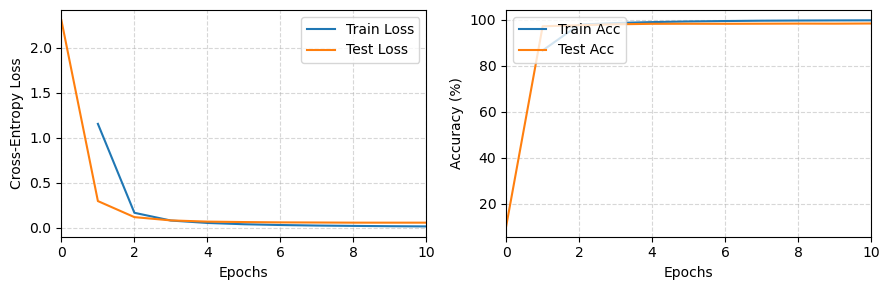

In [14]:
train_loss, train_acc, test_loss, test_acc = finetune(vit_finetune_all, cifar10_trainloader, cifar10_testloader, epoch_all, lr, gamma, cache_name='cifar10_vit_finetune_all')
plot(train_loss, train_acc, test_loss, test_acc)
torch.cuda.empty_cache()

load cache (create at 2023-49-06 19:06:26) from './results/.cache/analysis/image-embedding/pretrained-ViT-finetune/cifar10_vit_finetune_last-30.pkl'.


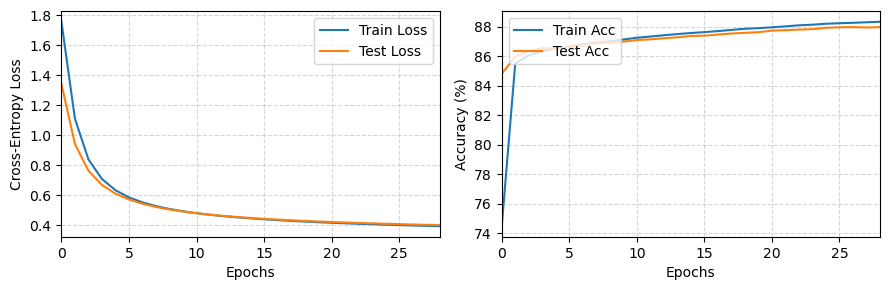

In [ ]:
train_loss, train_acc, test_loss, test_acc = finetune(vit_finetune_last_classifier, cifar10_trainloader, cifar10_testloader, epoch_last, lr, gamma, vit_finetune_last_embed, cache_name='cifar10_vit_finetune_last')
plot(train_loss, train_acc, test_loss, test_acc)
torch.cuda.empty_cache()

#### 1.1.2 Fintune ViT over CIFAR-100

In [ ]:
vit_finetune_all                  = ViTForImageClassification.from_pretrained(vit_name, num_labels=len(cifar100_trainset.classes), return_dict=False).to(device)
vit_finetune_last_embed           = ViTForImageClassification.from_pretrained(vit_name, num_labels=len(cifar100_trainset.classes), return_dict=False).to(device)
vit_finetune_last_classifier       = nn.Linear(vit_finetune_last_embed.classifier.in_features, len(cifar100_trainset.classes)).to(device)
vit_finetune_last_embed.classifier = nn.Identity().to(device)

Some weights of the model checkpoint at google/vit-base-patch16-224-in21k were not used when initializing ViTForImageClassification: ['pooler.dense.weight', 'pooler.dense.bias']
- This IS expected if you are initializing ViTForImageClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing ViTForImageClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of the model checkp

Results of finetuning all parameters versus finetuning the last layer's parameters of **ViT** over CIFAR-100. 

The total time comsumption of finetuning all parameters is , while the total time comsumption of finetuning the last layer's parameters is (all are conduced on one Nvidia RTX 3090).

load cache (create at 2023-05-06 21:06:56) from './results/.cache/analysis/image-embedding/pretrained-ViT-finetune/cifar100_vit_finetune_all-10.pkl'.


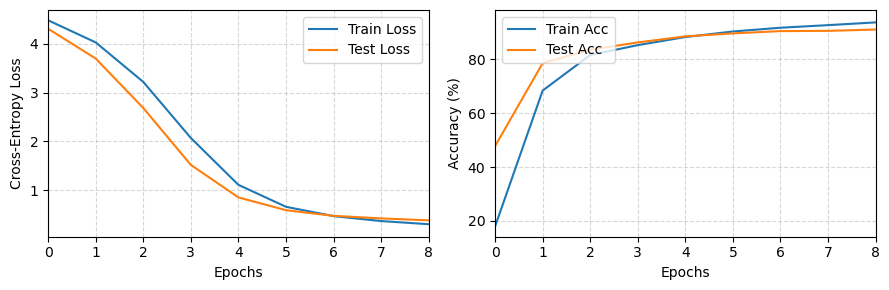

In [ ]:
train_loss, train_acc, test_loss, test_acc = finetune(vit_finetune_all, cifar100_trainloader, cifar100_testloader, epoch_all, lr, gamma, cache_name='cifar100_vit_finetune_all')
plot(train_loss, train_acc, test_loss, test_acc)
torch.cuda.empty_cache()

load cache (create at 2023-06-06 23:06:27) from './results/.cache/analysis/image-embedding/pretrained-ViT-finetune/cifar100_vit_finetune_last-30.pkl'.


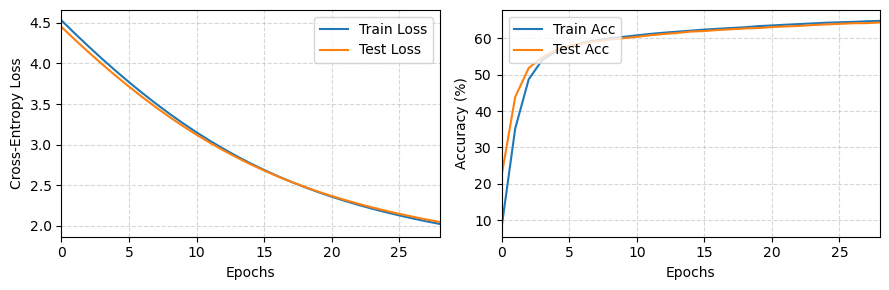

In [ ]:
train_loss, train_acc, test_loss, test_acc = finetune(vit_finetune_last_classifier, cifar100_trainloader, cifar100_testloader, epoch_last, lr, gamma, vit_finetune_last_embed, cache_name='cifar100_vit_finetune_last')
plot(train_loss, train_acc, test_loss, test_acc)
torch.cuda.empty_cache()

### 1.2 Fintune MAE over CIFAR Family
Then we discuss **finetuning all** parameters of *MAE* versus finetuning **the last layer's parameters** of *MAE* over CIFAR-10 / CIFAR-100.

In [ ]:
epoch_all  = 20
epoch_last = 100
lr    = 1e-2
gamma = 0.99

#### 1.2.1 Fintune MAE over CIFAR-10

In [ ]:
mae_finetune_all            = ViTMAE(num_labels=len(cifar10_trainset.classes)).to(device)
mae_finetune_last_embed     = ViTMAEEncoder().to(device)
mae_finetune_last_classifier = nn.Linear(mae_finetune_last_embed.mae.layernorm.normalized_shape[0], len(cifar10_trainset.classes)).to(device)

Some weights of the model checkpoint at facebook/vit-mae-base were not used when initializing ViTMAEModel: ['decoder.decoder_layers.3.attention.attention.key.weight', 'decoder.decoder_layers.5.intermediate.dense.weight', 'decoder.decoder_layers.1.layernorm_after.bias', 'decoder.decoder_layers.1.attention.attention.query.bias', 'decoder.decoder_layers.0.attention.attention.value.weight', 'decoder.decoder_layers.4.attention.output.dense.bias', 'decoder.decoder_layers.3.layernorm_after.weight', 'decoder.decoder_layers.3.attention.output.dense.weight', 'decoder.decoder_layers.5.attention.attention.key.bias', 'decoder.decoder_layers.5.attention.attention.key.weight', 'decoder.decoder_layers.5.layernorm_after.bias', 'decoder.decoder_layers.0.attention.attention.query.bias', 'decoder.decoder_layers.0.output.dense.weight', 'decoder.decoder_layers.7.attention.output.dense.weight', 'decoder.decoder_layers.7.attention.attention.key.weight', 'decoder.decoder_layers.0.layernorm_before.bias', 'decod

Results of finetuning all parameters versus finetuning the last layer's parameters of **MAE** over CIFAR-10. 

The total time comsumption of finetuning all parameters is , while the total time comsumption of finetuning the last layer's parameters is (all are conduced on one Nvidia RTX 3090).

In [ ]:
train_loss, train_acc, test_loss, test_acc = finetune(mae_finetune_all, cifar10_trainloader, cifar10_testloader, epoch_all, lr, gamma, cache_name='cifar10_mae_finetune_all')
plot(train_loss, train_acc, test_loss, test_acc)
torch.cuda.empty_cache()

  0%|          | 0/20 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
train_loss, train_acc, test_loss, test_acc = finetune(mae_finetune_last_classifier, cifar10_trainloader, cifar10_testloader, epoch_last, lr, gamma, mae_finetune_last_embed, cache_name='cifar10_mae_finetune_last')
plot(train_loss, train_acc, test_loss, test_acc)
torch.cuda.empty_cache()

#### 1.2.2 Fintune MAE over CIFAR-100

In [ ]:
mae_finetune_all            = ViTMAE(num_labels=len(cifar100_trainset.classes)).to(device)
mae_finetune_last_embed     = ViTMAEEncoder().to(device)
mae_finetune_last_classifier = nn.Linear(mae_finetune_last_embed.mae.layernorm.normalized_shape[0], len(cifar100_trainset.classes)).to(device)

Results of finetuning all parameters versus finetuning the last layer's parameters of **MAE** over CIFAR-100. 

The total time comsumption of finetuning all parameters is , while the total time comsumption of finetuning the last layer's parameters is (all are conduced on one Nvidia RTX 3090).

In [ ]:
train_loss, train_acc, test_loss, test_acc = finetune(mae_finetune_all, cifar100_trainloader, cifar100_testloader, epoch_all, lr, gamma, cache_name='cifar100_mae_finetune_all')
plot(train_loss, train_acc, test_loss, test_acc)
torch.cuda.empty_cache()

In [ ]:
train_loss, train_acc, test_loss, test_acc = finetune(mae_finetune_last_classifier, cifar100_trainloader, cifar100_testloader, epoch_last, lr, gamma, mae_finetune_last_embed, cache_name='cifar100_mae_finetune_last')
plot(train_loss, train_acc, test_loss, test_acc)
torch.cuda.empty_cache()

### 1.3 Fintune BEiT over CIFAR Family
Lastly, we discuss **finetuning all** parameters of *BEiT* versus finetuning **the last layer's parameters** of *BEiT* over CIFAR-10 / CIFAR-100.

In [ ]:
epoch_all  = 20
epoch_last = 50
lr    = 1e-2
gamma = 0.95

#### 1.3.1 Fintune BEiT over CIFAR-10

In [ ]:
beit_finetune_all                  = BeitForImageClassification.from_pretrained(beit_name, return_dict=False).to(device)
beit_finetune_all.classifier        = nn.Linear(beit_finetune_all.classifier.in_features, len(cifar10_trainset.classes)).to(device)
beit_finetune_last_embed           = BeitForImageClassification.from_pretrained(beit_name, return_dict=False).to(device)
beit_finetune_last_classifier       = nn.Linear(beit_finetune_last_embed.classifier.in_features, len(cifar10_trainset.classes)).to(device)
beit_finetune_last_embed.classifier = nn.Identity().to(device)

Results of finetuning all parameters versus finetuning the last layer's parameters of **BEiT** over CIFAR-10. 

The total time comsumption of finetuning all parameters is , while the total time comsumption of finetuning the last layer's parameters is (all are conduced on one Nvidia RTX 3090).

In [ ]:
train_loss, train_acc, test_loss, test_acc = finetune(beit_finetune_all, cifar10_trainloader, cifar10_testloader, epoch_all, lr, gamma, cache_name='cifar10_beit_finetune_all')
plot(train_loss, train_acc, test_loss, test_acc)
torch.cuda.empty_cache()

In [ ]:
train_loss, train_acc, test_loss, test_acc = finetune(beit_finetune_last_classifier, cifar10_trainloader, cifar10_testloader, epoch_last, lr, gamma, beit_finetune_last_embed, cache_name='cifar10_beit_finetune_last')
plot(train_loss, train_acc, test_loss, test_acc)
torch.cuda.empty_cache()

#### 1.3.2 Fintune BEiT over CIFAR-100

In [ ]:
beit_finetune_all                  = BeitForImageClassification.from_pretrained(beit_name, return_dict=False).to(device)
beit_finetune_all.classifier        = nn.Linear(beit_finetune_all.classifier.in_features, len(cifar100_trainset.classes)).to(device)
beit_finetune_last_embed           = BeitForImageClassification.from_pretrained(beit_name, return_dict=False).to(device)
beit_finetune_last_classifier       = nn.Linear(beit_finetune_last_embed.classifier.in_features, len(cifar100_trainset.classes)).to(device)
beit_finetune_last_embed.classifier = nn.Identity().to(device)

Results of finetuning all parameters versus finetuning the last layer's parameters of **BEiT** over CIFAR-100. 

The total time comsumption of finetuning all parameters is , while the total time comsumption of finetuning the last layer's parameters is (all are conduced on one Nvidia RTX 3090).

In [ ]:
train_loss, train_acc, test_loss, test_acc = finetune(beit_finetune_all, cifar100_trainloader, cifar100_testloader, epoch_all, lr, gamma, cache_name='cifar100_beit_finetune_all')
plot(train_loss, train_acc, test_loss, test_acc)
torch.cuda.empty_cache()

In [ ]:
train_loss, train_acc, test_loss, test_acc = finetune(beit_finetune_last_classifier, cifar100_trainloader, cifar100_testloader, epoch_last, lr, gamma, beit_finetune_last_embed, cache_name='cifar100_beit_finetune_last')
plot(train_loss, train_acc, test_loss, test_acc)
torch.cuda.empty_cache()

### 2. Performance of Pre-trained Models over Relatively High-Resolution Dataset (CalTech Family)

Then we load CalTech-101 and CalTech-256 dataset without augmentation transform and resize to $224 \times 224$.

In [ ]:
bs = 128

caltech101_trainset    = load_cv_dataset('caltech101', train=True, augment=False, resize=224)
caltech101_testset     = load_cv_dataset('caltech101', train=False, augment=False, resize=224)
caltech101_trainloader = DataLoader(caltech101_trainset, batch_size=bs, shuffle=True, num_workers=0)
caltech101_testloader  = DataLoader(caltech101_testset, batch_size=bs, shuffle=False, num_workers=0)
print('CalTech-101 training transform:\n' + '\n'.join([f'==> {str(t)}' for t in caltech101_trainset.transform.transforms]))
print('CalTech-101 test transform:\n' + '\n'.join([f'==> {str(t)}' for t in caltech101_testset.transform.transforms]))

caltech256_trainset    = load_cv_dataset('caltech256', train=True, augment=False, resize=224)
caltech256_testset     = load_cv_dataset('caltech256', train=False, augment=False, resize=224)
caltech256_trainloader = DataLoader(caltech256_trainset, batch_size=bs, shuffle=True, num_workers=0)
caltech256_testloader  = DataLoader(caltech256_testset, batch_size=bs, shuffle=False, num_workers=0)
print('CalTech-256 training transform:\n' + '\n'.join([f'==> {str(t)}' for t in caltech256_trainset.transform.transforms]))
print('CalTech-256 test transform:\n' + '\n'.join([f'==> {str(t)}' for t in caltech256_testset.transform.transforms]))

### 2.1 Fintune ViT over CalTech Family
We first discuss **finetuning all** parameters of *ViT* versus finetuning **the last layer's parameters** of *ViT* over CalTech-101 / CalTech-256.

In [ ]:
epoch_all  = 10
epoch_last = 30
lr    = 1e-2
gamma = 0.95

#### 2.1.1 Fintune ViT over CalTech-101

In [ ]:
vit_finetune_all                  = ViTForImageClassification.from_pretrained(vit_name, num_labels=len(caltech101_trainset.classes), return_dict=False).to(device)
vit_finetune_last_embed           = ViTForImageClassification.from_pretrained(vit_name, num_labels=len(caltech101_trainset.classes), return_dict=False).to(device)
vit_finetune_last_classifier       = nn.Linear(vit_finetune_last_embed.classifier.in_features, len(caltech101_trainset.classes)).to(device)
vit_finetune_last_embed.classifier = nn.Identity().to(device)

In [ ]:
train_loss, train_acc, test_loss, test_acc = finetune(vit_finetune_all, caltech101_trainloader, caltech101_testloader, epoch_all, lr, gamma, cache_name='caltech101_vit_finetune_all')
plot(train_loss, train_acc, test_loss, test_acc)
torch.cuda.empty_cache()

In [ ]:
train_loss, train_acc, test_loss, test_acc = finetune(vit_finetune_last_classifier, caltech101_trainloader, caltech101_testloader, epoch_last, lr, gamma, vit_finetune_last_embed, cache_name='caltech101_vit_finetune_last')
plot(train_loss, train_acc, test_loss, test_acc)
torch.cuda.empty_cache()

#### 2.1.2 Fintune ViT over CalTech-256

In [ ]:
vit_finetune_all                  = ViTForImageClassification.from_pretrained(vit_name, num_labels=len(caltech256_trainset.classes), return_dict=False).to(device)
vit_finetune_last_embed           = ViTForImageClassification.from_pretrained(vit_name, num_labels=len(caltech256_trainset.classes), return_dict=False).to(device)
vit_finetune_last_classifier       = nn.Linear(vit_finetune_last_embed.classifier.in_features, len(caltech256_trainset.classes)).to(device)
vit_finetune_last_embed.classifier = nn.Identity().to(device)

Results of finetuning all parameters versus finetuning the last layer's parameters of **ViT** over CalTech-256. 

The total time comsumption of finetuning all parameters is , while the total time comsumption of finetuning the last layer's parameters is (all are conduced on one Nvidia RTX 3090).

In [ ]:
train_loss, train_acc, test_loss, test_acc = finetune(vit_finetune_all, caltech256_trainloader, caltech256_testloader, epoch_all, lr, gamma, cache_name='caltech256_vit_finetune_all')
plot(train_loss, train_acc, test_loss, test_acc)
torch.cuda.empty_cache()

In [ ]:
train_loss, train_acc, test_loss, test_acc = finetune(vit_finetune_last_classifier, caltech256_trainloader, caltech256_testloader, epoch_last, lr, gamma, vit_finetune_last_embed, cache_name='caltech256_vit_finetune_last')
plot(train_loss, train_acc, test_loss, test_acc)
torch.cuda.empty_cache()

### 2.2 Fintune MAE over CalTech Family
Then we discuss **finetuning all** parameters of *MAE* versus finetuning **the last layer's parameters** of *MAE* over CalTech-101 / CalTech-256.

In [ ]:
epoch_all  = 20
epoch_last = 100
lr    = 1e-2
gamma = 0.95

#### 2.2.1 Fintune MAE over CalTech-101

In [ ]:
mae_finetune_all            = ViTMAE(num_labels=len(caltech101_trainset.classes)).to(device)
mae_finetune_last_embed     = ViTMAEEncoder().to(device)
mae_finetune_last_classifier = nn.Linear(mae_finetune_last_embed.mae.layernorm.normalized_shape[0], len(caltech101_trainset.classes)).to(device)

In [ ]:
train_loss, train_acc, test_loss, test_acc = finetune(mae_finetune_all, caltech101_trainloader, caltech101_testloader, epoch_all, lr, gamma, cache_name='caltech101_mae_finetune_all')
plot(train_loss, train_acc, test_loss, test_acc)
torch.cuda.empty_cache()

In [ ]:
train_loss, train_acc, test_loss, test_acc = finetune(mae_finetune_last_classifier, caltech101_trainloader, caltech101_testloader, epoch_last, lr, gamma, mae_finetune_last_embed, cache_name='caltech101_mae_finetune_last')
plot(train_loss, train_acc, test_loss, test_acc)
torch.cuda.empty_cache()

#### 2.2.2 Fintune MAE over CalTech-256

In [ ]:
mae_finetune_all            = ViTMAE(num_labels=len(caltech256_trainset.classes)).to(device)
mae_finetune_last_embed     = ViTMAEEncoder().to(device)
mae_finetune_last_classifier = nn.Linear(mae_finetune_last_embed.mae.layernorm.normalized_shape[0], len(caltech256_trainset.classes)).to(device)

Results of finetuning all parameters versus finetuning the last layer's parameters of **MAE** over CalTech-256. 

The total time comsumption of finetuning all parameters is , while the total time comsumption of finetuning the last layer's parameters is (all are conduced on one Nvidia RTX 3090).

In [ ]:
train_loss, train_acc, test_loss, test_acc = finetune(mae_finetune_all, caltech256_trainloader, caltech256_testloader, epoch_all, lr, gamma, cache_name='caltech256_mae_finetune_all')
plot(train_loss, train_acc, test_loss, test_acc)
torch.cuda.empty_cache()

In [ ]:
train_loss, train_acc, test_loss, test_acc = finetune(mae_finetune_last_classifier, caltech256_trainloader, caltech256_testloader, epoch_last, lr, gamma, mae_finetune_last_embed, cache_name='caltech256_mae_finetune_last')
plot(train_loss, train_acc, test_loss, test_acc)
torch.cuda.empty_cache()

### 2.3 Fintune BEiT over CalTech Family

Lastly, we discuss **finetuning all** parameters of *BEiT* versus finetuning **the last layer's parameters** of *BEiT* over CalTech-101 / CalTech-256.

In [ ]:
epoch_all  = 20
epoch_last = 50
lr    = 1e-2
gamma = 0.95

#### 2.3.1 Fintune BEiT over CalTech-101

In [ ]:
beit_finetune_all                  = BeitForImageClassification.from_pretrained(beit_name, return_dict=False).to(device)
beit_finetune_all.classifier        = nn.Linear(beit_finetune_all.classifier.in_features, len(caltech101_trainset.classes)).to(device)
beit_finetune_last_embed           = BeitForImageClassification.from_pretrained(beit_name, return_dict=False).to(device)
beit_finetune_last_classifier       = nn.Linear(beit_finetune_last_embed.classifier.in_features, len(caltech101_trainset.classes)).to(device)
beit_finetune_last_embed.classifier = nn.Identity().to(device)

Results of finetuning all parameters versus finetuning the last layer's parameters of **BEiT** over CalTech-101. 

The total time comsumption of finetuning all parameters is , while the total time comsumption of finetuning the last layer's parameters is (all are conduced on one Nvidia RTX 3090).

In [ ]:
train_loss, train_acc, test_loss, test_acc = finetune(beit_finetune_all, caltech101_trainloader, caltech101_testloader, epoch_all, lr, gamma, cache_name='caltech101_beit_finetune_all')
plot(train_loss, train_acc, test_loss, test_acc)
torch.cuda.empty_cache()

In [ ]:
train_loss, train_acc, test_loss, test_acc = finetune(beit_finetune_last_classifier, caltech101_trainloader, caltech101_testloader, epoch_last, lr, gamma, beit_finetune_last_embed, cache_name='caltech101_beit_finetune_last')
plot(train_loss, train_acc, test_loss, test_acc)
torch.cuda.empty_cache()

#### 2.3.2 Fintune BEiT over CalTech-256

In [ ]:
beit_finetune_all                  = BeitForImageClassification.from_pretrained(beit_name, return_dict=False).to(device)
beit_finetune_all.classifier        = nn.Linear(beit_finetune_all.classifier.in_features, len(caltech256_trainset.classes)).to(device)
beit_finetune_last_embed           = BeitForImageClassification.from_pretrained(beit_name, return_dict=False).to(device)
beit_finetune_last_classifier       = nn.Linear(beit_finetune_last_embed.classifier.in_features, len(caltech256_trainset.classes)).to(device)
beit_finetune_last_embed.classifier = nn.Identity().to(device)

Results of finetuning all parameters versus finetuning the last layer's parameters of **BEiT** over CalTech-256. 

The total time comsumption of finetuning all parameters is , while the total time comsumption of finetuning the last layer's parameters is (all are conduced on one Nvidia RTX 3090).

In [ ]:
train_loss, train_acc, test_loss, test_acc = finetune(beit_finetune_all, caltech256_trainloader, caltech256_testloader, epoch_all, lr, gamma, cache_name='caltech256_beit_finetune_all')
plot(train_loss, train_acc, test_loss, test_acc)
torch.cuda.empty_cache()

In [ ]:
train_loss, train_acc, test_loss, test_acc = finetune(beit_finetune_last_classifier, caltech256_trainloader, caltech256_testloader, epoch_last, lr, gamma, beit_finetune_last_embed, cache_name='caltech256_beit_finetune_last')
plot(train_loss, train_acc, test_loss, test_acc)
torch.cuda.empty_cache()

### 3. Performance of Pre-trained Models over Relatively High-Resolution Dataset (ImageNet-1k)